In [6]:
# Import libraries required for data loading, analysis and visualization.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the ASOS product dataset.
df = pd.read_csv('products_asos.csv', on_bad_lines='skip')

# Convert price values to numeric format. Invalid values are replaced with NaN for further cleaning.
df['price']=pd.to_numeric(df['price'], errors='coerce')
df=df.dropna(subset=['price'])

# Check the number of records available after initial data cleaning.
print(f"Data loaded: {len(df)} rows")

# Preview the first records to verify the dataset structure.
df.head()

Data loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [19]:
# Convert product descriptions to string format.
df['description'] = df['description'].astype(str)

# Extract the brand name from the product description.
def get_brand(text):
    
     # Look for the "by" pattern used in product descriptions.
    if 'by ' in text:
        try:
            
             # Extract the first word after "by" as the brand name.
            return text.split('by ')[1].split(' ')[0]
        except:

            # Assign "Unknown" when the brand cannot be extracted.
            return "Unknown"

             # Assign "Unknown" when the expected brand pattern is missing.
    return "Unknown"

df['brand_raw'] = df['description'].apply(get_brand)

# Check the extracted brand information.
df.head()

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...,StradivariusJacket


In [33]:
# Standardize brand names that were extracted inconsistently.
brand_map={
    'New':'New_look',
    'River':'River_island',
    'Miss':'Miss selfridge',
    'TopshopWelcome':'Topshop'
}

# Apply the brand mapping and keep the original value.
df['Brand']=df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

# Count the number of products for each brand.
brand_counts=df['Brand'].value_counts()

# Keep brands represented by more than 5 products
valid_brands=brand_counts[brand_counts>5].index

# Create a cleaned dataset containing only sufficiently.
df_clean=df[df['Brand'].isin(valid_brands)].copy()

# Display the most frequently represented brands.
print(df_clean['Brand'].value_counts().head(5))

Brand
ASOS              4844
Topshiop           711
New_look           511
River_island       467
Miss selfridge     429
Name: count, dtype: int64


In [43]:
def calculate_phantom_revenue(size_str):

     # Return zero values when size information is missing or stored in an unexpected format.
    if not isinstance(size_str, str):
        return 0, 0.0

      # Split the size information into individual sizes.
    sizes = size_str.split(',')
    total_sizes = len(sizes)

    # Count how many sizes are marked as "Out of stock".
    out_of_stock_count = size_str.count('Out of stock')

    # Calculate the share of unavailable sizes.
    rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0
    return out_of_stock_count, rate

# Apply the stockout calculation to every product.
metrics=df_clean['size'].apply(lambda x:calculate_phantom_revenue(x))
df_clean['Stockout_Count']=[x[0] for x in metrics]
df_clean['Stockout_Rate']=[x[1] for x in metrics]
df_clean['Lost_Revenue']=df_clean['price']*df_clean['Stockout_Count']
cols=['Brand', 'name', 'price', 'Stockout_Count', 'Lost_Revenue']

# Display the five products with the highest estimated.
print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(5)[cols])

          Brand                                               name  price  \
2941    Barbour               Barbour Beadnell wax jacket in black  219.0   
21948  Topshiop  Topshop premium real leather collared zip thro...  260.0   
2715       ASOS  ASOS DESIGN premium real leather trench coat i...  220.0   
15584      ASOS  ASOS EDITION geo embellished fringe plunge mid...  250.0   
29838  Topshiop           Topshop Baggy co-ord jeans in green cord   50.0   

       Stockout_Count  Lost_Revenue  
2941                9        1971.0  
21948               7        1820.0  
2715                7        1540.0  
15584               6        1500.0  
29838              27        1350.0  


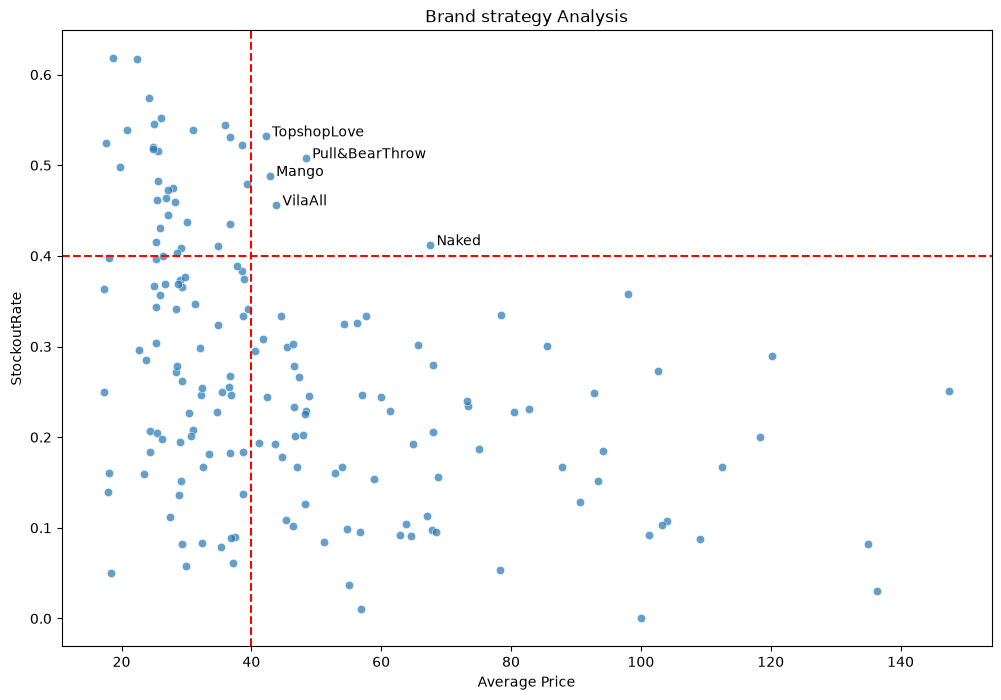

In [61]:
# Aggregate product-level metrics by brand.

brand_strategy=df_clean.groupby('Brand').agg({
    'price':'mean',
    'Stockout_Rate':'mean',
    'Lost_Revenue':'mean',
    'name':'count'
}).reset_index()

# Ensure that price and stockout rate are stored as numeric values for further analysis.
brand_strategy['price'] = pd.to_numeric(brand_strategy['price'], errors='coerce')
brand_strategy['Stockout_Rate'] = pd.to_numeric(brand_strategy['Stockout_Rate'], errors='coerce')

# Keep brands with more than 10 products to avoid conclusions based on very small samples.
brand_strategy=brand_strategy[brand_strategy['name']>10]

# Visualize the relationship between average product price and average stockout rate across brands.
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=brand_strategy, 
    x='price', 
    y='Stockout_Rate',
    sizes=(50, 500),
    alpha=0.7,
)

# Identify brands with both relatively high prices and high stockout rates.
winners=brand_strategy[
    (brand_strategy['price']>40) &
    (brand_strategy['Stockout_Rate']>0.4)
]

# Add brand names to the selected points
for i in range(len(winners)):
    plt.text(
        winners.iloc[i]['price']+1,
        winners.iloc[i]['Stockout_Rate'],
        winners.iloc[i]['Brand']
    )

# Add chart title and axis labels.
plt.title('Brand strategy Analysis')
plt.xlabel('Average Price')
plt.ylabel('StockoutRate')

# Add reference lines for the price and stockout thresholds used to identify potentially important brands
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')
plt.show()